## This notebook will generate dataframes for correlating ccf-aligned injection sites with various behavior metrics from dynamic routing performance and trials tables

In [2]:
import os
import polars as pl
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import datetime
import zoneinfo
import npc_lims
from dynamic_routing_analysis import data_utils, spike_utils

ModuleNotFoundError: No module named 'polars'

In [2]:
import npc_sessions
from npc_sessions import DynamicRoutingSession

In [3]:
# from tissuecyte_injections_coords_utils import sort_structures_by_region
from tissuecyte_injections_coords_utils import load_csv_annotations
from tissuecyte_injections_coords_utils import get_structure_info_for_annotations

In [4]:
from tissuecyte_injections_coords_utils import get_annotation
from tissuecyte_injections_coords_utils import tree

#load annotation volume
annotation, meta = get_annotation()

## Clean Neuroglancer DataFrame

In [6]:
# Extract date from label (format: region_hemisphere_MM-DD-YYYY) and create session_id
# Convert MM-DD-YYYY to YYYY-MM-DD format for session_id

neuroglancer_annotations_df = pl.read_parquet(r"Z:\vayle\neuroglancer_injections_coords\neuroglancer_injections_coords.parquet")

neuroglancer_annotations_df = neuroglancer_annotations_df.with_columns(
    # Extract date portion after last underscore: MM-DD-YYYY
    pl.col("label").str.extract(r"(\d{1,2})-(\d{1,2})-(\d{4})$", 1).str.zfill(2).alias("month"),
    pl.col("label").str.extract(r"(\d{1,2})-(\d{1,2})-(\d{4})$", 2).str.zfill(2).alias("day"),
    pl.col("label").str.extract(r"(\d{1,2})-(\d{1,2})-(\d{4})$", 3).alias("year"),
).with_columns(
    # Format as YYYY-MM-DD
    (pl.col("year") + "-" + pl.col("month") + "-" + pl.col("day")).alias("date")
).with_columns(
    (pl.col("mouse_id") + "_" + pl.col("date")).alias("session_id")
).drop(["month", "day", "year"]).with_columns(
    # Round up AP, ML, DV to integers
    pl.col("AP").ceil().cast(pl.Int64),
    pl.col("ML").ceil().cast(pl.Int64),
    pl.col("DV").ceil().cast(pl.Int64),
    # Remove date from label (e.g., "ORBvl_LH_07-30-2025" -> "ORBvl_LH")
    pl.col("label").str.replace(r"_\d{1,2}-\d{1,2}-\d{4}$", "").alias("target_brain_region"),
    # Remove list brackets from description (e.g., "['text']" -> "text")
    pl.col("description").str.replace_all(r"[\[\]']", ""),
).drop("label")

neuroglancer_annotations_df

mouse_id,description,AP,DV,ML,date,session_id,target_brain_region
str,str,i64,i64,i64,str,str,str
"""767405""","""45 nL nonconjugated muscimol""",216,359,701,"""2025-05-20""","""767405_2025-05-20""","""ORBvl_LH"""
"""767405""","""45 nL nonconjugated muscimol""",217,393,471,"""2025-05-20""","""767405_2025-05-20""","""ORBvl_RH"""
"""767405""","""45 nL nonconjugated muscimol""",220,357,697,"""2025-05-29""","""767405_2025-05-29""","""ORBvl_LH"""
"""767405""","""45 nL nonconjugated muscimol""",219,394,471,"""2025-05-29""","""767405_2025-05-29""","""ORBvl_RH"""
"""767405""","""45 nL nonconjugated muscimol""",494,354,774,"""2025-05-23""","""767405_2025-05-23""","""DLS_LH"""
…,…,…,…,…,…,…,…
"""807743""","""45 nL nonconjugated muscimol""",294,398,424,"""2025-11-14""","""807743_2025-11-14""","""AId_RH"""
"""807743""","""360 nL conjugated muscimol""",289,346,635,"""2025-11-04""","""807743_2025-11-04""","""ORBm_LH"""
"""807743""","""360 nL conjugated muscimol""",303,337,563,"""2025-11-04""","""807743_2025-11-04""","""ORBm_RH"""


## Clean Tissuecyte DataFrame

In [7]:
tissuecyte_annotations = load_csv_annotations(r"Z:\Muscimol\injections_ccf_coordinates")
tissuecyte_annotations_df = pl.concat(
	[
		pl.from_pandas(df).with_columns(pl.lit(filename).alias("mouse_id"))
		for filename, df in tissuecyte_annotations.items()
	],
	how="vertical_relaxed",
)
tissuecyte_annotations_df = tissuecyte_annotations_df.drop(["Unnamed: 0"]).with_columns(
	pl.col("mouse_id").str.replace(r"\.csv$", "")
)
tissuecyte_annotations_df

AP,DV,ML,session_id,mouse_id
i64,i64,i64,str,str
252,405,675,"""728053_2024-11-19""","""728053"""
260,400,460,"""728053_2024-11-19""","""728053"""
475,300,430,"""728053_2024-11-21""","""728053"""
437,332,710,"""728053_2024-11-21""","""728053"""
877,235,480,"""737412_2024-12-19""","""737412"""
…,…,…,…,…
262,380,677,"""774916_2025-03-25""","""774916"""
505,330,710,"""774916_2025-04-04""","""774916"""
507,327,435,"""774916_2025-04-04""","""774916"""


## Clean VS200 slide scanner dataframe

In [1]:
# Import VS200 slide scanner .xlsx file with Pinpoint injection coordinates and descriptions
vs200_annotations_df = pl.read_excel(r"Z:\Vayle\Muscimol\VS200_slide scanner_muscimol_injection_coords.xlsx")
vs200_annotations_df

NameError: name 'pl' is not defined

In [ ]:
# Convert Pinpoint coordinates to CCF (10um resolution) and add session_id and injection description information
# Original coords are in μm, bregma-relative (bregma = 0,0,0)

# Step 1: Take absolute value of original coordinates
vs200_annotations_df = vs200_annotations_df.with_columns(
    pl.col("AP").abs().alias("AP_abs"),
    pl.col("DV").abs().alias("DV_abs"),
    pl.col("ML").abs().alias("ML_abs"),
)

# Step 2: Convert to 10μm resolution  (divide by 10, round to 3 digits)
vs200_annotations_df = vs200_annotations_df.with_columns(
    (pl.col("AP_abs") / 10).round(0).cast(pl.Int64).alias("AP"),
    (pl.col("DV_abs") / 10).round(0).cast(pl.Int64).alias("DV"),
    (pl.col("ML_abs") / 10).round(0).cast(pl.Int64).alias("ML"),
).drop(["AP_abs", "DV_abs", "ML_abs"])

vs200_annotations_df

## Combine VS200, Tissuecyte, and Neuroglancer dataframes

In [8]:
# Vertically concatenate both dataframes - matching columns get appended, unique columns filled with nulls
injections_df = pl.concat(
    [tissuecyte_annotations_df, neuroglancer_annotations_df],
    how="diagonal_relaxed"
)

In [ ]:
injections_df

AP,DV,ML,session_id,mouse_id,description,date,target_brain_region
i64,i64,i64,str,str,str,str,str
252,405,675,"""728053_2024-11-19""","""728053""",null,null,null
260,400,460,"""728053_2024-11-19""","""728053""",null,null,null
475,300,430,"""728053_2024-11-21""","""728053""",null,null,null
437,332,710,"""728053_2024-11-21""","""728053""",null,null,null
877,235,480,"""737412_2024-12-19""","""737412""",null,null,null
…,…,…,…,…,…,…,…
294,398,424,"""807743_2025-11-14""","""807743""","""45 nL nonconjugated muscimol""","""2025-11-14""","""AId_RH"""
289,346,635,"""807743_2025-11-04""","""807743""","""360 nL conjugated muscimol""","""2025-11-04""","""ORBm_LH"""
303,337,563,"""807743_2025-11-04""","""807743""","""360 nL conjugated muscimol""","""2025-11-04""","""ORBm_RH"""


## Concatenate trials table to CCF-aligned injections coordinates table

In [9]:
session = '767405_2025-05-19'
session = npc_sessions.Session(session)

In [ ]:
# Get trials and performance data for all sessions and join to injections_df
trials_list = []
performance_list = []

# Get unique session_ids from injections_df
session_ids = injections_df.select("session_id").drop_nulls().unique().to_series().to_list()

for session_id in session_ids:
    try:
        session = npc_sessions.Session(session_id)
        
        # Get trials table and add session_id
        trials = pl.from_pandas(session.trials[:]).with_columns(
            pl.lit(session_id).alias("session_id")
        )
        trials_list.append(trials)
        
        # Get performance table and add session_id
        performance = pl.from_pandas(session.performance[:]).with_columns(
            pl.lit(session_id).alias("session_id")
        )
        performance_list.append(performance)
        
        print(f"Loaded: {session_id}")
    except Exception as e:
        print(f"Failed to load {session_id}: {e}")

        # Combine all trials and performance data
if trials_list:
    all_trials_df = pl.concat(trials_list, how="diagonal_relaxed")
if performance_list:
    all_performance_df = pl.concat(performance_list, how="diagonal_relaxed")

print(f"\nLoaded {len(trials_list)} sessions")

# Join injections with trials (each injection row repeats for each trial)
injections_with_trials_df = injections_df.join(
    all_trials_df,
    on="session_id",
    how="left"
)

# Join injections with performance (summary metrics per session)
injections_with_performance_df = injections_df.join(
    all_performance_df,
    on="session_id", 
    how="left"
)

print(f"Injections with trials: {injections_with_trials_df.shape}")
print(f"Injections with performance: {injections_with_performance_df.shape}")

Loaded: 774916_2025-03-25
Loaded: 739828_2025-02-11
Loaded: 782106_2025-07-08
Loaded: 789937_2025-10-14
Loaded: 774470_2025-07-22
Loaded: 746138_2024-12-18
Loaded: 789937_2025-10-21
Loaded: 807743_2025-11-11
Loaded: 805749_2025-10-31
Loaded: 805749_2025-10-24
Loaded: 767405_2025-05-23
Loaded: 774916_2025-04-01
Loaded: 807743_2025-11-07
Loaded: 805749_2025-10-21
Loaded: 782106_2025-07-11
Loaded: 728053_2024-11-19
Loaded: 772657_2025-03-04
Loaded: 807742_2025-10-07
Loaded: 807743_2025-11-04
Loaded: 805749_2025-10-28
Loaded: 767405_2025-05-20
Loaded: 772657_2025-02-28
Loaded: 774916_2025-04-04
Loaded: 728053_2024-11-21
Loaded: 789937_2025-10-17
Loaded: 767405_2025-05-29
Loaded: 739828_2025-02-18
Loaded: 782106_2025-07-15
Loaded: 739828_2025-02-14
Loaded: 807742_2025-09-30
Loaded: 774470_2025-07-30
Loaded: 789937_2025-10-24
Loaded: 774916_2025-03-28
Loaded: 737412_2024-12-19
Loaded: 739828_2025-02-21
Loaded: 807743_2025-11-14
Loaded: 772657_2025-02-25

Loaded 37 sessions
Injections with tr

In [ ]:
injections_with_trials_df

AP,DV,ML,session_id,mouse_id,description,date,target_brain_region,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,grating_phase,block_index,rewarded_modality,trial_index,trial_index_in_block,repeat_index,is_response,is_correct,is_incorrect,is_hit,is_false_alarm,is_correct_reject,is_miss,is_go,is_nogo,is_rewarded,is_noncontingent_reward,is_contingent_reward,is_reward_scheduled,is_instruction,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
i64,i64,i64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,i64,str,i64,f64,f64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
252,405,675,"""728053_2024-11-19""","""728053""",null,null,null,3.236053,8.740673,3.236053,4.703986,4.737342,5.237738,4.820754,5.738155,null,null,5.738155,5.738155,8.740673,"""vis1""",0.0,0,"""vis""",0,0.0,0.0,false,false,true,false,false,false,true,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false
252,405,675,"""728053_2024-11-19""","""728053""",null,null,null,8.974202,14.4788,8.974202,10.442126,10.475775,10.976055,10.55886,11.476294,null,null,11.476294,11.476294,14.4788,"""vis1""",0.5,0,"""vis""",1,1.0,0.0,false,false,true,false,false,false,true,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false
252,405,675,"""728053_2024-11-19""","""728053""",null,null,null,15.346192,20.850827,15.346192,16.814038,16.847449,17.347866,16.930851,17.848291,17.397911,17.397911,17.414596,17.848291,20.850827,"""vis1""",0.5,0,"""vis""",2,2.0,0.0,true,true,false,true,false,false,false,true,false,true,false,true,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false
252,405,675,"""728053_2024-11-19""","""728053""",null,null,null,22.201958,27.706541,22.201958,23.669853,23.703214,24.203607,23.786618,24.704058,24.453842,24.453842,24.4705,24.704058,27.706541,"""vis1""",0.5,0,"""vis""",3,3.0,0.0,true,true,false,true,false,false,false,true,false,true,false,true,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false
252,405,675,"""728053_2024-11-19""","""728053""",null,null,null,33.64484,39.182839,33.64484,35.112737,35.146128,35.646514,35.229501,36.146936,null,null,36.146936,36.146936,39.182839,"""vis1""",0.0,0,"""vis""",4,4.0,0.0,false,false,true,false,false,false,true,true,false,true,true,false,true,true,false,true,false,true,false,true,false,false,false,true,false,false,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
301,337,562,"""807743_2025-11-11""","""807743""","""360 nL conjugated muscimol""","""2025-11-11""","""ORBm_RH""",3608.677258,3614.198554,3608.677258,3610.145184,3610.178538,3610.678538,3610.26192,3611.179388,null,null,null,3611.179388,3614.198554,"""sound1""",null,5,"""vis""",516,86.0,0.0,false,true,false,false,false,true,false,false,true,false,false,false,false,false,true,false,false,true,true,false,false,false,false,true,false,false,false,false,false
301,337,562,"""807743_2025-11-11""","""807743""","""360 nL conjugated muscimol""","""2025-11-11""","""ORBm_RH""",3614.482125,3620.036817,3614.482125,3615.96674,3616.000093,3616.000093,3616.083499,3617.017611,null,null,null,3617.017611,3620.036817,"""catch""",null,5,"""vis""",517,87.0,0.0,false,true,false,false,false,false,false,false,false,false,false,false,false,false,false,false,true,false,false,false,false,false,false,true,

In [18]:
injections_with_performance_df

AP,DV,ML,session_id,mouse_id,description,date,target_brain_region,start_time,stop_time,block_index,n_trials,n_responses,n_hits,n_contingent_rewards,hit_rate,false_alarm_rate,catch_response_rate,rewarded_modality,is_first_block_aud,cross_modality_dprime,signed_cross_modality_dprime,vis_dprime,aud_dprime,vis_target_response_rate,vis_nontarget_response_rate,aud_target_response_rate,aud_nontarget_response_rate,CCF_Structure
i64,i64,i64,str,str,str,str,str,f64,f64,i64,i64,i64,i64,i64,f64,f64,f64,str,bool,f64,f64,f64,f64,f64,f64,f64,f64,str
252,405,675,"""728053_2024-11-19""","""728053""",null,null,null,3.236053,604.506242,0,91,21,2,2,0.08,0.345455,1.909091,"""vis""",false,-1.544782,-1.544782,0.509434,-1.848494,0.0,0.0,0.555556,0.473684,"""Anterior olfactory nucleus"""
252,405,675,"""728053_2024-11-19""","""728053""",null,null,null,604.606335,1211.847935,1,87,42,23,23,0.958333,0.38,3.230769,"""aud""",false,2.882014,-2.882014,-0.269513,-0.131067,0.125,0.055556,1.0,1.0,"""Anterior olfactory nucleus"""
252,405,675,"""728053_2024-11-19""","""728053""",null,null,null,1211.914684,1816.33723,2,85,44,9,9,0.391304,0.648148,5.5,"""vis""",false,-2.213853,-2.213853,1.317298,-3.124763,0.388889,0.055556,1.0,0.882353,"""Anterior olfactory nucleus"""
252,405,675,"""728053_2024-11-19""","""728053""",null,null,null,1816.837633,2422.678006,3,90,45,23,23,1.0,0.385965,4.5,"""aud""",false,3.022234,-3.022234,-0.318075,0.39923,0.157895,0.052632,1.0,0.947368,"""Anterior olfactory nucleus"""
252,405,675,"""728053_2024-11-19""","""728053""",null,null,null,2423.39527,3025.682687,4,84,44,14,14,0.608696,0.588235,4.4,"""vis""",false,-1.317298,-1.317298,1.810042,-2.455901,0.777778,0.0625,0.944444,0.705882,"""Anterior olfactory nucleus"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
301,337,562,"""807743_2025-11-11""","""807743""","""360 nL conjugated muscimol""","""2025-11-11""","""ORBm_RH""",605.775066,1214.118748,1,82,24,12,12,0.5,0.244898,2.666667,"""vis""",true,0.157311,0.157311,1.501086,-1.098022,0.578947,0.066667,0.4375,0.222222,"""Infralimbic area, layer 1"""
301,337,562,"""807743_2025-11-11""","""807743""","""360 nL conjugated muscimol""","""2025-11-11""","""ORBm_RH""",1216.454007,1820.410593,2,87,17,9,9,0.375,0.125,2.428571,"""aud""",true,0.61026,-0.61026,-0.269654,0.717794,0.176471,0.052632,0.263158,0.15,"""Infralimbic area, layer 1"""
301,337,562,"""807743_2025-11-11""","""807743""","""360 nL conjugated muscimol""","""2025-11-11""","""ORBm_RH""",1820.460663,2428.787582,3,91,26,7,7,0.28,0.322034,3.714286,"""vis""",true,-0.51683,-0.51683,0.25878,-1.413531,0.3,0.2,0.473684,0.3,"""Infralimbic area, layer 1"""


## Get CCF Structures

In [11]:
# Get structure info and add as new column
structure_names = get_structure_info_for_annotations(injections_df, annotation, tree)
injections_df = injections_df.with_columns(
    pl.Series("ccf_structure", structure_names)
)

Coord: (252, 405, 675) | Structure: Anterior olfactory nucleus
Coord: (260, 400, 460) | Structure: Orbital area, ventrolateral part, layer 1
Coord: (475, 300, 430) | Structure: Caudoputamen
Coord: (437, 332, 710) | Structure: Caudoputamen
Coord: (877, 235, 480) | Structure: Superior colliculus, motor related, intermediate white layer
Coord: (875, 230, 620) | Structure: Superior colliculus, motor related, intermediate white layer
Coord: (305, 380, 470) | Structure: Orbital area, ventrolateral part, layer 5
Coord: (327, 370, 720) | Structure: Orbital area, lateral part, layer 5
Coord: (352, 367, 720) | Structure: Orbital area, lateral part, layer 6a
Coord: (297, 375, 467) | Structure: Orbital area, ventrolateral part, layer 5
Coord: (855, 202, 505) | Structure: Superior colliculus, motor related, intermediate gray layer
Coord: (857, 200, 655) | Structure: Superior colliculus, optic layer
Coord: (855, 202, 500) | Structure: Superior colliculus, optic layer
Coord: (850, 190, 657) | Structu

In [19]:
# Create dataframe with AP, DV, ML and CCF structure
ccf_structures = injections_df.select(["AP", "DV", "ML"]).with_columns(
    pl.Series("CCF_Structure", structure_names)
)
ccf_structures

AP,DV,ML,CCF_Structure
i64,i64,i64,str
252,405,675,"""Anterior olfactory nucleus"""
260,400,460,"""Orbital area, ventrolateral pa…"
475,300,430,"""Caudoputamen"""
437,332,710,"""Caudoputamen"""
877,235,480,"""Superior colliculus, motor rel…"
…,…,…,…
294,398,424,"""Orbital area, lateral part, la…"
289,346,635,"""Orbital area, ventrolateral pa…"
303,337,563,"""Infralimbic area, layer 1"""


In [ ]:
# Create CCF structures + session ID and injection description information

## CCF Strcutures with Performance

In [14]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [22]:
# Join CCF structure onto injections_with_performance_df based on AP, DV, ML
# Drop existing CCF_Structure columns to allow re-running this cell
cols_to_drop = [c for c in injections_with_performance_df.columns if "CCF_Structure" in c]
if cols_to_drop:
    injections_with_performance_df = injections_with_performance_df.drop(cols_to_drop)

injections_with_performance_df = injections_with_performance_df.join(
    ccf_structures,
    on=["AP", "DV", "ML"],
    how="left"
)
injections_with_performance_df

injections_with_performance_df.to_pandas().to_excel(r"Z:\Muscimol\ccf_labeled_injections_with_performance.xlsx")

In [21]:
# Join CCF structure onto injections_with_performance_df based on AP, DV, ML
injections_with_performance_df = injections_with_performance_df.join(
    ccf_structures,
    on=["AP", "DV", "ML"],
    how="left"
)
injections_with_performance_df

injections_with_performance_df.to_pandas().to_excel(r"Z:\Muscimol\ccf_labeled_injections_with_performance.xlsx")

DuplicateError: column with name 'CCF_Structure_right' already exists

You may want to try:
- renaming the column prior to joining
- using the `suffix` parameter to specify a suffix different to the default one ('_right')

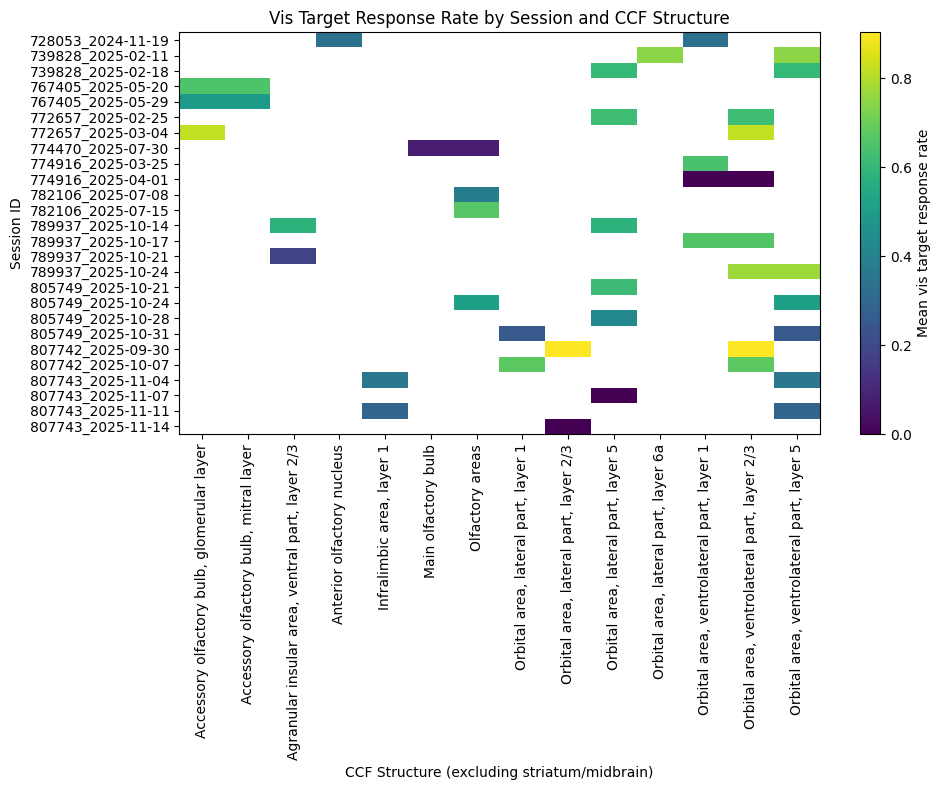

In [ ]:
# Compare mean visual target response rate by session_id and CCF structure
perf_df = injections_with_performance_df

# Resolve column names robustly
structure_col = "CCF_Structure" if "CCF_Structure" in perf_df.columns else "ccf_structure"
vis_target_col = next(
    c for c in perf_df.columns
    if ("vis_target" in c.lower()) and ("response_rate" in c.lower())
)

# Exclude striatum/midbrain-related structures
exclude_keywords = [
    "striatum", "caudoputamen", "nucleus accumbens",
    "midbrain", "superior colliculus", "substantia nigra", "ventral tegmental", "ventricle"
]

filtered = (
    perf_df
    .filter(
        pl.col(structure_col).is_not_null() &
        ~pl.col(structure_col).str.to_lowercase().str.contains("|".join(exclude_keywords))
    )
    .group_by(["session_id", structure_col])
    .agg(pl.col(vis_target_col).mean().alias("mean_vis_target_response_rate"))
)

# Pivot for heatmap: rows=session_id, cols=CCF structure
heatmap_df = (
    filtered
    .to_pandas()
    .pivot(index="session_id", columns=structure_col, values="mean_vis_target_response_rate")
    .sort_index()
)

plt.figure(figsize=(max(10, heatmap_df.shape[1] * 0.5), max(8, heatmap_df.shape[0] * 0.25)))
im = plt.imshow(heatmap_df.fillna(np.nan), aspect="auto", cmap="viridis", interpolation="none")
plt.colorbar(im, label="Mean vis target response rate")
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=90)
plt.xlabel("CCF Structure (excluding striatum/midbrain)")
plt.ylabel("Session ID")
plt.title("Vis Target Response Rate by Session and CCF Structure")
plt.tight_layout()
plt.show()

## Plot some behavior metric versus ccf coord on annotation volume

In [ ]:
from tissuecyte_injections_coords_utils import reference_space_key
from tissuecyte_injections_coords_utils import rsp
from tissuecyte_injections_coords_utils import rspc
reference_space_key = "annotation/ccf_2022"

In [ ]:
%pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------------- -------------------------- 3.4/9.9 MB 28.9 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.9 MB 48.2 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 24.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
%pip install nbformat>=4.2.0

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
# Plot coords in CCF space colored by vis target response rate -coronal
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# Get the vis target response rate column
vis_target_col = next(
    c for c in injections_with_performance_df.columns
    if ("vis_target" in c.lower()) and ("response_rate" in c.lower())
)
structure_col = "CCF_Structure" if "CCF_Structure" in injections_with_performance_df.columns else "ccf_structure"

# Convert to pandas for plotting
plot_df = injections_with_performance_df.select(
    ["AP", "DV", "ML", "session_id", structure_col, vis_target_col]
).drop_nulls(subset=["AP", "DV", "ML", vis_target_col]).to_pandas()

# Exclude caudatoputamen, ventricle, and colliculus structures
exclude_keywords = ['caudoputamen', 'caudatoputamen', 'ventricle', 'colliculus']
mask = ~plot_df[structure_col].str.lower().str.contains('|'.join(exclude_keywords), na=True)
plot_df = plot_df[mask].copy()

# Add percentage column for display
plot_df['vis_target_pct'] = plot_df[vis_target_col] * 100

ap_index = 400  # AP slice index for coronal view

# Get coronal slice image from reference space
try:
    # Axis 0 = coronal (AP slicing direction)
    slice_image = rsp.get_slice_image(0, ap_index * 10)
    def rgb2gray(rgb):
        return np.dot(rgb[..., :3], [0.2989, 0.5870, 0.1140])
    gray_image = rgb2gray(slice_image)
    has_background = True
except Exception as e:
    print(f"Could not load coronal slice image: {e}")
    has_background = False

# Create figure with coronal slice background
fig = go.Figure()

# Add coronal slice background image
if has_background:
    fig.add_trace(go.Image(
        z=np.stack([gray_image, gray_image, gray_image], axis=-1).astype(np.uint8),
        x0=0,
        y0=0,
        dx=1140 / gray_image.shape[1],  # Scale to ML axis
        dy=800 / gray_image.shape[0],   # Scale to DV axis
        opacity=0.6
    ))

# Add scatter plot on top
fig.add_trace(go.Scatter(
    x=plot_df['ML'],
    y=plot_df['DV'],
    mode='markers',
    marker=dict(
        size=12,
        color=plot_df['vis_target_pct'],
        colorscale='RdBu_r',
        cmin=0,
        cmax=100,
        line=dict(width=1, color='black'),
        colorbar=dict(title='Vis Target<br>Response Rate (%)')
    ),
    customdata=plot_df[['session_id', structure_col, 'ML', 'DV', 'AP', 'vis_target_pct']].values,
    hovertemplate='<b>Session:</b> %{customdata[0]}<br>' +
                  '<b>Structure:</b> %{customdata[1]}<br>' +
                  '<b>ML:</b> %{x:.0f} μm<br>' +
                  '<b>DV:</b> %{y:.0f} μm<br>' +
                  '<b>AP:</b> %{customdata[4]:.0f} μm<br>' +
                  '<b>Response Rate:</b> %{customdata[5]:.1f}%<extra></extra>'
))

# Update layout
fig.update_layout(
    title=f'CCF Coronal Injection Sites Colored by Vis Target Response Rate',
    xaxis=dict(title='ML', range=[0, 1140]),
    yaxis=dict(title='DV', range=[800, 0], scaleanchor='x'),  # Invert y-axis
    width=900,
    height=700,
    showlegend=False
)

fig.show()

In [ ]:
# Plot coords in CCF space colored by vis target response rate - sagittal
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from PIL import Image

# Get the vis target response rate column
vis_target_col = next(
    c for c in injections_with_performance_df.columns
    if ("vis_target" in c.lower()) and ("response_rate" in c.lower())
)
structure_col = "CCF_Structure" if "CCF_Structure" in injections_with_performance_df.columns else "ccf_structure"

# Convert to pandas for plotting
plot_df = injections_with_performance_df.select(
    ["AP", "DV", "ML", "session_id", structure_col, vis_target_col]
).drop_nulls(subset=["AP", "DV", "ML", vis_target_col]).to_pandas()

# Exclude caudatoputamen, ventricle, and colliculus structures
exclude_keywords = ['caudoputamen', 'caudatoputamen', 'ventricle', 'colliculus']
mask = ~plot_df[structure_col].str.lower().str.contains('|'.join(exclude_keywords), na=True)
plot_df = plot_df[mask].copy()

# Add percentage column for display
plot_df['vis_target_pct'] = plot_df[vis_target_col] * 100

# Use median ML of the data points for the slice
ml_index = int(plot_df['ML'].median())
print(f"Using ML slice at {ml_index*10} μm (median of injection points)")
print(f"AP range of points: {plot_df['AP'].min()*10} - {plot_df['AP'].max()*10} μm")
print(f"DV range of points: {plot_df['DV'].min()*10} - {plot_df['DV'].max()*10} μm")

# Get sagittal slice image from reference space
try:
    # Axis 2 = sagittal (ML slicing direction)
    slice_image = rsp.get_slice_image(2, ml_index * 10)
    def rgb2gray(rgb):
        return np.dot(rgb[..., :3], [0.2989, 0.5870, 0.1140])
    gray_image = rgb2gray(slice_image)
    # Transpose to match matplotlib's imshow with .T and extent order
    gray_image = gray_image.T
    has_background = True
except Exception as e:
    print(f"Could not load sagittal slice image: {e}")
    has_background = False

# Create figure with sagittal slice background
fig = go.Figure()

# Add sagittal slice background image
if has_background:
    # Convert to RGB uint8 and create PIL Image
    img_rgb = np.stack([gray_image, gray_image, gray_image], axis=-1).astype(np.uint8)
    pil_img = Image.fromarray(img_rgb)
    
    # Match matplotlib's extent=[1320, 0, 800, 0] behavior
    # Image goes from x=1320 (left edge) to x=0 (right edge), y=800 (bottom) to y=0 (top)
    fig.add_layout_image(
        dict(
            source=pil_img,
            xref="x",
            yref="y",
            x=1320,  # Left edge of image
            y=0,     # Top edge of image (since y-axis is inverted)
            sizex=1320,
            sizey=800,
            xanchor="left",
            yanchor="top",
            sizing="stretch",
            opacity=0.6,
            layer="below"
        )
    )

# Add scatter plot on top - flip AP for proper orientation (matching matplotlib: 1320 - AP)
fig.add_trace(go.Scatter(
    x=1320 - plot_df['AP'],  # Flip AP for sagittal orientation
    y=plot_df['DV'],
    mode='markers',
    marker=dict(
        size=12,
        color=plot_df['vis_target_pct'],
        colorscale='RdBu_r',
        cmin=0,
        cmax=100,
        line=dict(width=1, color='black'),
        colorbar=dict(title='Vis Target<br>Response Rate (%)')
    ),
    customdata=plot_df[['session_id', structure_col, 'ML', 'DV', 'AP', 'vis_target_pct']].values,
    hovertemplate='<b>Session:</b> %{customdata[0]}<br>' +
                  '<b>Structure:</b> %{customdata[1]}<br>' +
                  '<b>ML:</b> %{customdata[2]:.0f} μm<br>' +
                  '<b>DV:</b> %{y:.0f} μm<br>' +
                  '<b>AP:</b> %{customdata[4]:.0f} μm<br>' +
                  '<b>Response Rate:</b> %{customdata[5]:.1f}%<extra></extra>'
))

# Update layout - reverse x-axis to match matplotlib extent=[1320, 0, ...]
fig.update_layout(
    title=f'CCF Sagittal View Injection Sites Colored by Vis Target Response Rate',
    xaxis=dict(title='AP', range=[1320, 0], autorange=False),  # Reversed to match matplotlib
    yaxis=dict(title='DV', range=[800, 0], scaleanchor='x'),   # Inverted y-axis
    width=1100,
    height=700,
    showlegend=False
)

fig.show()

Using ML slice at 6300 μm (median of injection points)
AP range of points: 2120 - 3520 μm
DV range of points: 3050 - 4620 μm
